# Boundary Data Exploration

Loads and verifies two map files:
1. 2020 precinct boundaries (old map)
2. 2026 congressional district boundaries (new map)

Both need to load correctly and share the same coordinate system before any analysis can happen.

## Step 1 — Load 2020 precinct boundaries

Statewide Texas file: 9,014 precincts total. We filter to Travis County later.

In [1]:
import geopandas as gpd
import os

# Load the 2020 precinct boundaries
precincts = gpd.read_file('../data/raw/boundaries/precincts20g_2020.zip')

print("2020 Precincts loaded successfully")
print(f"Number of precincts: {len(precincts)}")
print(f"CRS: {precincts.crs}")
print(f"Columns: {list(precincts.columns)}")

2020 Precincts loaded successfully
Number of precincts: 9014
CRS: PROJCS["NAD_1983_Lambert_Conformal_Conic",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AUTHORITY["EPSG","4269"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",31.1666666666667],PARAMETER["central_meridian",-100],PARAMETER["standard_parallel_1",27.4166666666667],PARAMETER["standard_parallel_2",34.9166666666667],PARAMETER["false_easting",1000000],PARAMETER["false_northing",1000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Columns: ['CNTY', 'COLOR', 'PREC', 'PCTKEY', 'cntykey', 'Shape_area', 'Shape_len', 'geometry']


## Step 2 — Inspect the 2026 district file

The district shapefile is nested inside a subfolder in the zip. 
This cell confirms the file structure before loading it.

In [3]:
import zipfile

with zipfile.ZipFile('../data/raw/boundaries/PLANC2333.zip', 'r') as z:
    print(z.namelist())

['PLANC2333/PLANC2333.cpg', 'PLANC2333/PLANC2333.dbf', 'PLANC2333/PLANC2333.prj', 'PLANC2333/PLANC2333.sbn', 'PLANC2333/PLANC2333.sbx', 'PLANC2333/PLANC2333.shp', 'PLANC2333/PLANC2333.shx']


## Step 3 — Load the 2026 congressional district boundaries

Note the file path syntax — the shapefile lives inside a subfolder 
within the zip, so we point directly to it.

In [4]:
districts = gpd.read_file('zip://../data/raw/boundaries/PLANC2333.zip!PLANC2333/PLANC2333.shp')

print("2026 Congressional Districts loaded successfully")
print(f"Number of districts: {len(districts)}")
print(f"CRS: {districts.crs}")
print(f"Columns: {list(districts.columns)}")

2026 Congressional Districts loaded successfully
Number of districts: 38
CRS: PROJCS["NAD_1983_Lambert_Conformal_Conic",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AUTHORITY["EPSG","4269"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",31.1666666666667],PARAMETER["central_meridian",-100],PARAMETER["standard_parallel_1",27.4166666666667],PARAMETER["standard_parallel_2",34.9166666666667],PARAMETER["false_easting",1000000],PARAMETER["false_northing",1000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Columns: ['District', 'geometry']


## Step 4 — Find Travis County's code in the precinct file

The CNTY field uses numeric county codes, not county names. 
This cell shows us what values exist so we can identify Travis County (code 453).

In [6]:
# See what CNTY values look like
print(precincts['CNTY'].unique()[:20])

[ 55 113 201  69 117 189  65 359  45 129  17 195  87 421 155 205 295 375
 437 211]


## Step 5 — Filter to Travis County

Confirm that filtering by CNTY == 453 returns the right precincts.

In [7]:
# Search for Travis County by looking at the data differently
# Let's see if there's a way to identify counties
print(precincts[precincts['CNTY'] == 453])

      CNTY  COLOR  PREC   PCTKEY  cntykey    Shape_area     Shape_len  \
4466   453      4  0370  4530370      227  8.634729e+07  59614.958426   
4467   453      6  0369  4530369      227  3.612775e+07  37855.431469   
4468   453      1  0371  4530371      227  1.708521e+08  92466.476821   
4469   453      7  0372  4530372      227  3.442283e+07  34912.526602   
4646   453      1  0303  4530303      227  2.307987e+07  22004.044115   
...    ...    ...   ...      ...      ...           ...           ...   
4930   453      2  0137  4530137      227  1.394215e+07  17917.467190   
4931   453      5  0123  4530123      227  3.370307e+07  26557.767254   
4932   453      4  0163  4530163      227  2.227357e+07  23790.033947   
8527   453      3  0106  4530106      227  1.457830e+08  84685.976930   
8528   453      1  0107  4530107      227  8.846099e+07  49561.240648   

                                               geometry  
4466  POLYGON ((1197608.722 940290.282, 1198265.917 ...  
4467  P

## Step 6 — Save the Travis County precinct filter

247 precincts confirmed. This is our working dataset for the pilot.

In [8]:
travis_precincts = precincts[precincts['CNTY'] == 453]

print(f"Travis County precincts: {len(travis_precincts)}")

Travis County precincts: 247


## Step 7 — Visualize both layers together

Plots the 2020 precincts (blue) against the 2026 district boundaries (red).
The red lines show how the new congressional districts carve through Travis County.
7 districts touch Travis County, the large shapes extending outward 
connect Austin's urban voters to surrounding rural areas.

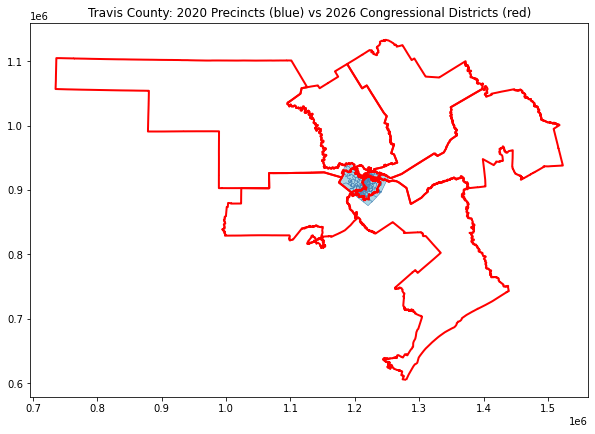

Congressional districts touching Travis County: 7


In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot Travis County precincts in blue
travis_precincts.plot(ax=ax, color='lightblue', edgecolor='steelblue', linewidth=0.5)

# Filter districts that overlap Travis County and plot in red outline
travis_districts = districts[districts.intersects(travis_precincts.unary_union)]
travis_districts.plot(ax=ax, color='none', edgecolor='red', linewidth=2)

ax.set_title('Travis County: 2020 Precincts (blue) vs 2026 Congressional Districts (red)')
plt.show()

print(f"Congressional districts touching Travis County: {len(travis_districts)}")

## Step 8 — Identify which districts touch Travis County

Districts 10, 11, 17, 21, 27, 31, and 37 all cut through Travis County.

In [11]:
print(travis_districts['District'].values)

[10 11 17 21 27 31 37]


In [12]:
# Save filtered Travis County data for use in later notebooks
travis_precincts.to_file('../data/processed/travis_precincts_2020.gpkg', driver='GPKG')
travis_districts.to_file('../data/processed/travis_districts_2026.gpkg', driver='GPKG')

print("Saved Travis County precincts and districts to /data/processed/")

Saved Travis County precincts and districts to /data/processed/


In [13]:
notes = """# Boundary Data Notes

## 2020 Precinct Boundaries
- **Source:** Texas Legislative Council Capitol Data Portal
- **URL:** https://data.capitol.texas.gov/dataset/precincts
- **File:** precincts20g_2020.zip
- **Download date:** May 2026
- **CRS:** NAD 1983 Lambert Conformal Conic
- **Total precincts (statewide):** 9,014
- **Travis County precincts:** 247
- **Key fields:** CNTY (county code), PREC (precinct name), PCTKEY (unique ID)
- **Notes:** CNTY field is numeric. Travis County code is 453.

## 2026 Congressional District Boundaries (PlanC2333)
- **Source:** Texas Legislative Council Capitol Data Portal
- **URL:** https://data.capitol.texas.gov/dataset/planc2333
- **File:** PLANC2333.zip
- **Download date:** May 2026
- **CRS:** NAD 1983 Lambert Conformal Conic (matches precinct file exactly)
- **Total districts:** 38
- **Districts touching Travis County:** 7 (Districts 10, 11, 17, 21, 27, 31, 37)
- **Key fields:** District (district number)
- **Notes:** Shapefile is nested inside PLANC2333/ subfolder within the zip.
  Load with: gpd.read_file('zip://path/PLANC2333.zip!PLANC2333/PLANC2333.shp')
- **Legal status:** PlanC2333 enacted by 89th Legislature, 2nd C.S., 2025.
  Subject to ongoing litigation as of early 2026; U.S. Supreme Court stay
  in effect keeping PlanC2333 operative for 2026 elections.

## CRS Notes
Both files use identical CRS — no reprojection needed before spatial join.
"""

with open('../data/raw/boundaries/boundaries_notes.md', 'w') as f:
    f.write(notes)

print("boundaries_notes.md saved")

boundaries_notes.md saved
